In [1]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir("."))


Current working directory:
D:\projects\fraud-detection\notebooks

Files here:
['.ipynb_checkpoints', '01_eda.ipynb']


In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape


(284807, 31)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df['Class'].value_counts()


Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
fraud_percentage = (df['Class'].sum() / len(df)) * 100
fraud_percentage


np.float64(0.1727485630620034)

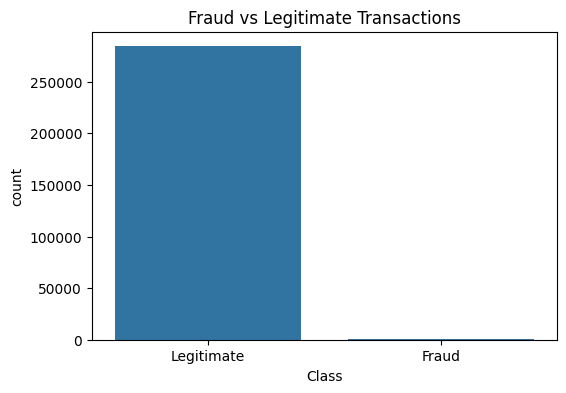

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Legitimate Transactions")
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.show()


In [8]:
# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

X.shape, y.shape


((284807, 30), (284807,))

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((227845, 30), (56962, 30))

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
from sklearn.linear_model import LogisticRegression

# Create model
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # VERY IMPORTANT for imbalanced data
    random_state=42
)

# Train model
log_reg.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [12]:
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_proba))


Confusion Matrix:
[[55478  1386]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


ROC-AUC Score:
0.9720834996210077


In [14]:
# Fraud risk score (0–100)
risk_score = y_pred_proba * 100

risk_score[:10]


array([5.69097592e-01, 6.75524185e+00, 1.19034013e-02, 1.51307336e+00,
       9.45553607e+01, 1.32231174e+00, 7.92909018e-02, 2.70493967e+00,
       6.42405084e+00, 4.41924480e-01])

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [16]:
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_proba = rf_model.predict_proba(X_test)[:, 1]


In [17]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_rf_proba))


Confusion Matrix:
[[56849    15]
 [   18    80]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score:
0.9747259483421957


In [18]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance.head(10)


,feature,importance
14,V14,0.180699
4,V4,0.113959
10,V10,0.113530
12,V12,0.095465
17,V17,0.088187
3,V3,0.063327
11,V11,0.055879
16,V16,0.051472
2,V2,0.030135
7,V7,0.025239


In [19]:
import xgboost


In [20]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight (VERY IMPORTANT for imbalance)
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_xgb_proba))


Confusion Matrix:
[[56852    12]
 [   16    82]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score:
0.974856406406119


In [22]:
# Fraud risk score (0–100)
risk_score_xgb = y_pred_xgb_proba * 100
risk_score_xgb[:10]


array([2.3496696e-05, 7.6995355e-05, 2.2109518e-04, 5.5901073e-06,
       6.4840047e-03, 1.8807237e-05, 9.4356856e-06, 2.1896672e-05,
       2.4278984e-04, 4.2156127e-05], dtype=float32)

In [23]:
import shap
import numpy as np

# Define a callable prediction function
def predict_proba_fn(X):
    return xgb_model.predict_proba(X)[:, 1]


In [24]:
# Sample data for background (small for speed)
X_background = X_train.sample(100, random_state=42)

explainer = shap.Explainer(
    predict_proba_fn,
    X_background
)


In [25]:
X_sample = X_test.sample(500, random_state=42)

shap_values = explainer(X_sample)


PermutationExplainer explainer: 501it [00:56,  8.28it/s]                                                                                                                                                    


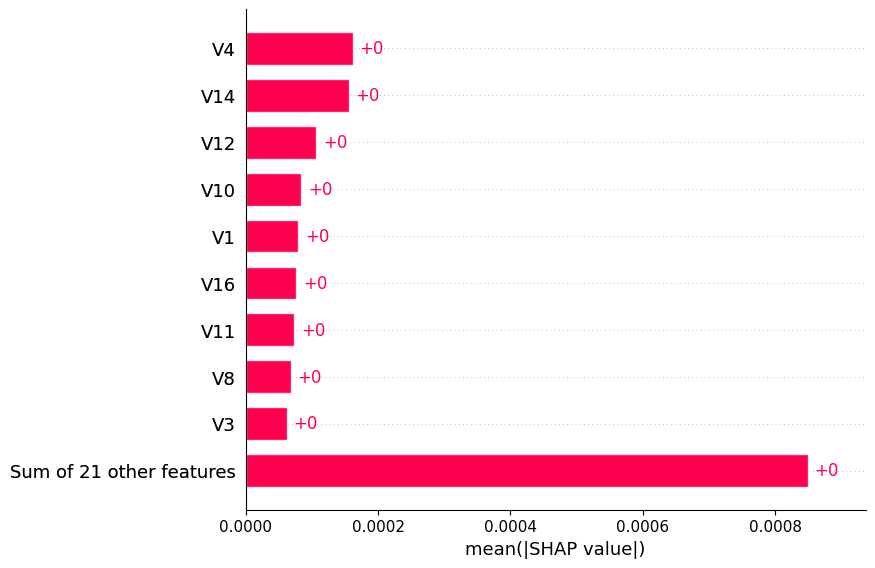

In [26]:
shap.plots.bar(shap_values)


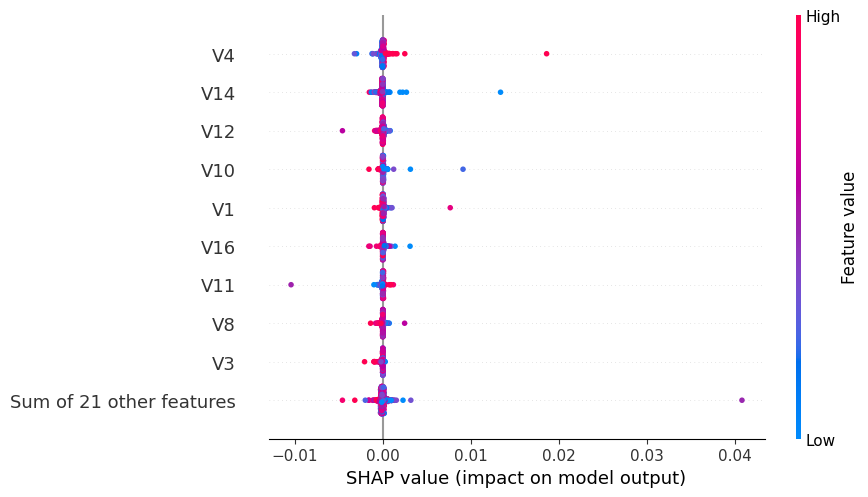

In [27]:
shap.plots.beeswarm(shap_values)


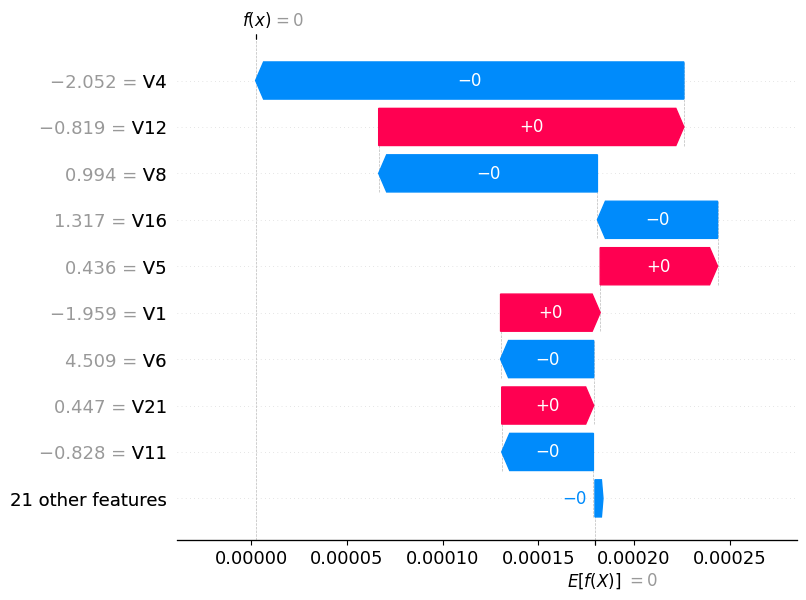

In [28]:
shap.plots.waterfall(shap_values[0])


In [29]:
import joblib

joblib.dump(xgb_model, "../src/xgb_fraud_model.pkl")
joblib.dump(scaler, "../src/scaler.pkl")

print("Model and scaler saved successfully")


Model and scaler saved successfully


In [ ]:
model = joblib.load("xgb_fraud_model.pkl")
scaler = joblib.load("scaler.pkl")
